In [1]:
import pandas as pd
import numpy as np

# 读取 Excel 文件
file_path = 'combined_df.xlsx'  # 替换为你的 Excel 文件路径
df = pd.read_excel(file_path)

# 计算 cpr estimate 和 level deviation
df['CPR_estimate'] = np.exp(np.log(df['S_CP'])-df['deviation'].shift(1))

df['level_CPR_deviation'] = df['S_CP'] - df['CPR_estimate']

df_filtered = df[['Date','level_CPR_deviation']]

# 读取数据
#df_a = pd.read_excel('CPRdev_construction_workingdays.xlsx')

#df_new = pd.merge(df_a[['Date','CPRdev']], df[['Date','level_CPR_deviation']], on='Date', how='left')

#output_file_path = 'combined_deviation.xlsx'  # 替换为输出文件路径
#df_new.to_excel(output_file_path, index=False)

output_file_path = 'level_deviation.xlsx'  # 替换为输出文件路径
df_filtered.to_excel(output_file_path, index=False)

In [2]:
import pandas as pd
import numpy as np

# 读取 Excel 文件
file_path = 'combined_df.xlsx'  # 替换为你的 Excel 文件路径
df = pd.read_excel(file_path)

# 计算 cpr estimate 和 log deviation
df['CPR_estimate'] = np.exp(np.log(df['S_CP'])-df['deviation'].shift(1))

df['CPR_deviation'] = np.log(df['S_CP']) - np.log(df['CPR_estimate'])

df_filtered = df[['Date','close','CPR_estimate','CPR_deviation']]

# 将结果写入新的 Excel 文件
output_file_path = '17-24CPR_deviation.xlsx'  # 替换为输出文件路径
df_filtered.to_excel(output_file_path, index=False)

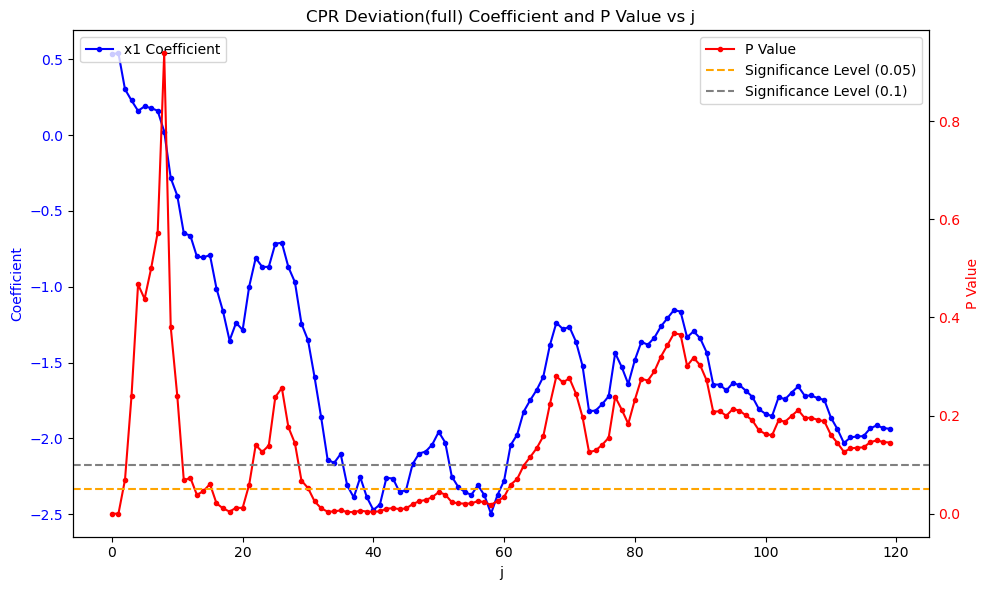

In [3]:
#CPR deviation regression
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

# 读取数据
df_a = pd.read_excel('17-24CPR_deviation.xlsx')
df_b = pd.read_excel('new_pillar1724.xlsx')

# 合并数据
df = pd.merge(df_a, df_b[['Date', 'St+1NT', 'StDT','S_CP']], on='Date', how='left')

# 确保日期列是日期类型
df['Date'] = pd.to_datetime(df['Date'])

# 创建完整的日期范围
#full_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max())

# 创建一个新的 DataFrame，包含完整的日期范围
#df_full = pd.DataFrame(full_range, columns=['Date'])

# 合并原始 DataFrame 和完整日期 DataFrame
#df_merged = pd.merge(df_full, df, on='Date', how='left')

#df = df_merged

df['CLt-1']= np.log(df['close'].shift(1))
df['CLpillar_change']= np.log(df['close'].shift(1)) - np.log(df['close'].shift(2))
df['NTpillar_change']= np.log(df['St+1NT'].shift(1)/df['S_CP'].shift(1)) - np.log(df['St+1NT'].shift(2)/df['S_CP'].shift(2))
#df['DTpillar_change']= np.log(df['StDT'].shift(1)/df['S_CP'].shift(1)) - np.log(df['StDT'].shift(2)/df['S_CP'].shift(2))


start_date = '2017-01-01'
end_date = '2024-12-31'

# 筛选指定日期范围内的行
mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
filtered_df = df[mask]

df = filtered_df


# 获取原始 DataFrame 的行数
num_rows = len(df)

# 循环 j 从 0 到 119
for j in range(120):
    # 创建新的列名
    new_column_name = f'j_{j}'
    
    # 计算新列的值并添加到原始 DataFrame
    df[new_column_name] = np.log(df['close'].shift(-j)) - np.log(df['close'].shift(1))

df.to_excel('CPR_deviation_regression_data.xlsx', index=False)
    
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 < 2
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(full) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('17-24CPR_deviation_full_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('17-24CPR_deviation_full_regression_results.xlsx', index=False)

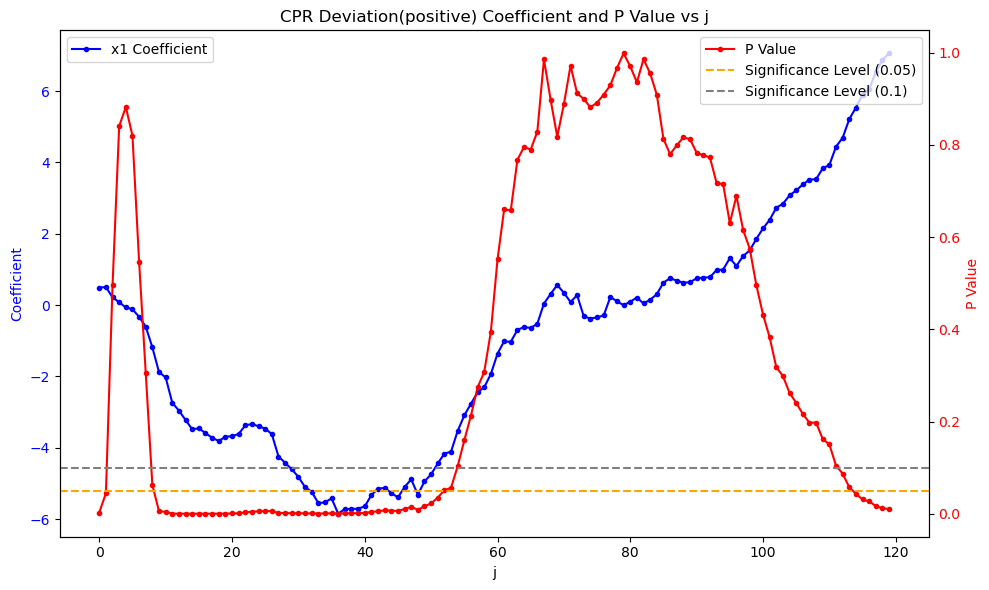

In [4]:
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 > 0
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(positive) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('17-24CPR_deviation_positive_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('17-24CPR_deviation_positive_regression_results.xlsx', index=False)

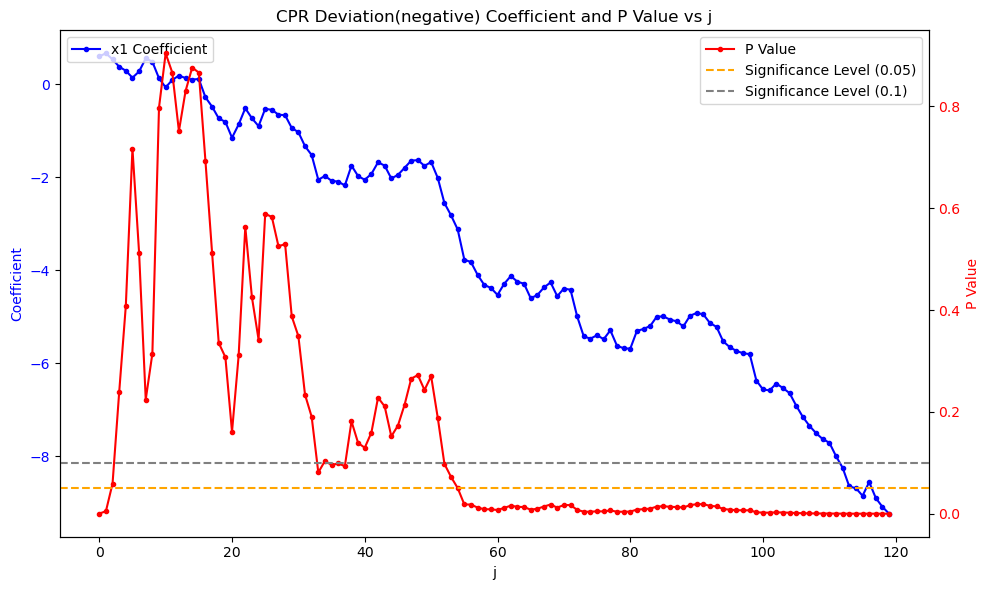

In [5]:
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 <0
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(negative) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('17-24CPR_deviation_negative_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('17-24CPR_deviation_negative_regression_results.xlsx', index=False)

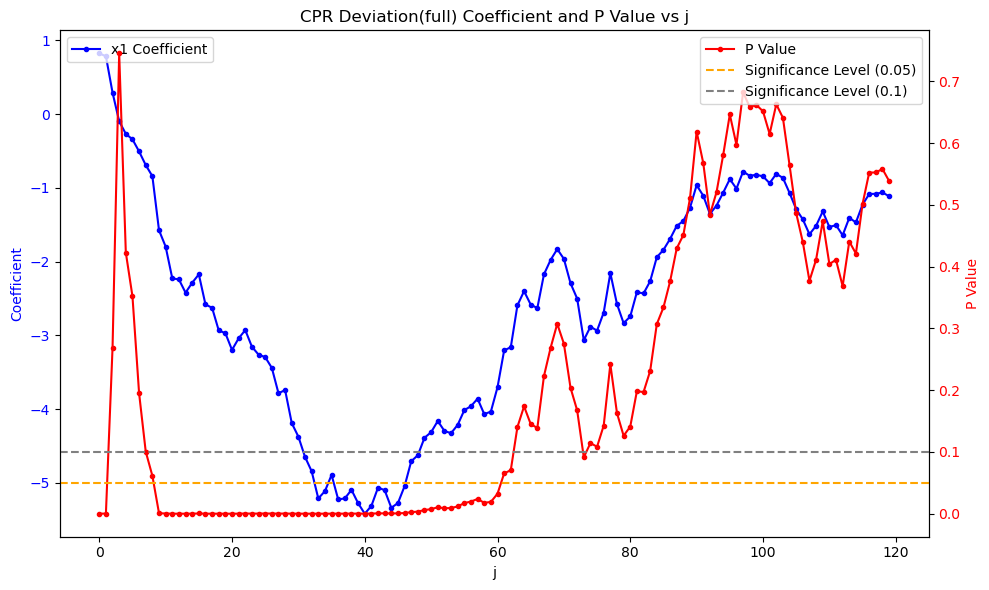

In [6]:
#CPR deviation regression
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

# 读取数据
df_a = pd.read_excel('17-24CPR_deviation.xlsx')
df_b = pd.read_excel('new_pillar1724.xlsx')

# 合并数据
df = pd.merge(df_a, df_b[['Date', 'St+1NT', 'StDT','S_CP']], on='Date', how='left')

# 确保日期列是日期类型
df['Date'] = pd.to_datetime(df['Date'])

# 创建完整的日期范围
#full_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max())

# 创建一个新的 DataFrame，包含完整的日期范围
#df_full = pd.DataFrame(full_range, columns=['Date'])

# 合并原始 DataFrame 和完整日期 DataFrame
#df_merged = pd.merge(df_full, df, on='Date', how='left')

#df = df_merged

df['CLt-1']= np.log(df['close'].shift(1))
df['CLpillar_change']= np.log(df['close'].shift(1)) - np.log(df['close'].shift(2))
df['NTpillar_change']= np.log(df['St+1NT'].shift(1)/df['S_CP'].shift(1)) - np.log(df['St+1NT'].shift(2)/df['S_CP'].shift(2))
#df['DTpillar_change']= np.log(df['StDT'].shift(1)/df['S_CP'].shift(1)) - np.log(df['StDT'].shift(2)/df['S_CP'].shift(2))


start_date = '2021-01-01'
end_date = '2024-12-31'

# 筛选指定日期范围内的行
mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
filtered_df = df[mask]

df = filtered_df


# 获取原始 DataFrame 的行数
num_rows = len(df)

# 循环 j 从 0 到 119
for j in range(120):
    # 创建新的列名
    new_column_name = f'j_{j}'
    
    # 计算新列的值并添加到原始 DataFrame
    df[new_column_name] = np.log(df['close'].shift(-j)) - np.log(df['close'].shift(1))

df.to_excel('CPR_deviation_regression_data2124.xlsx', index=False)
    
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 < 2
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(full) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('21-24CPR_deviation_full_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('21-24CPR_deviation_full_regression_results.xlsx', index=False)

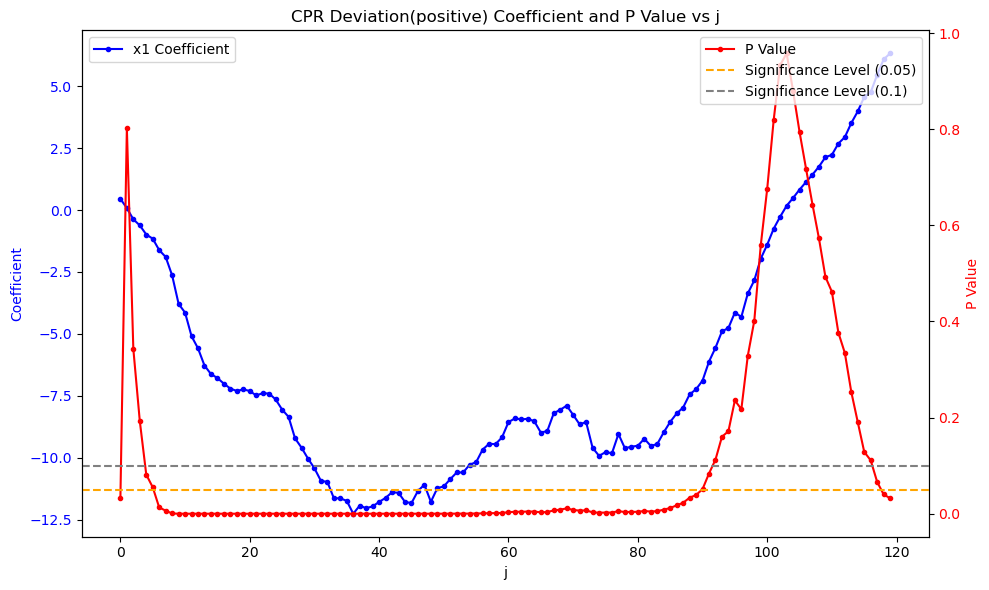

In [7]:
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 > 0
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(positive) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('21-24CPR_deviation_positive_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('21-24CPR_deviation_positive_regression_results.xlsx', index=False)

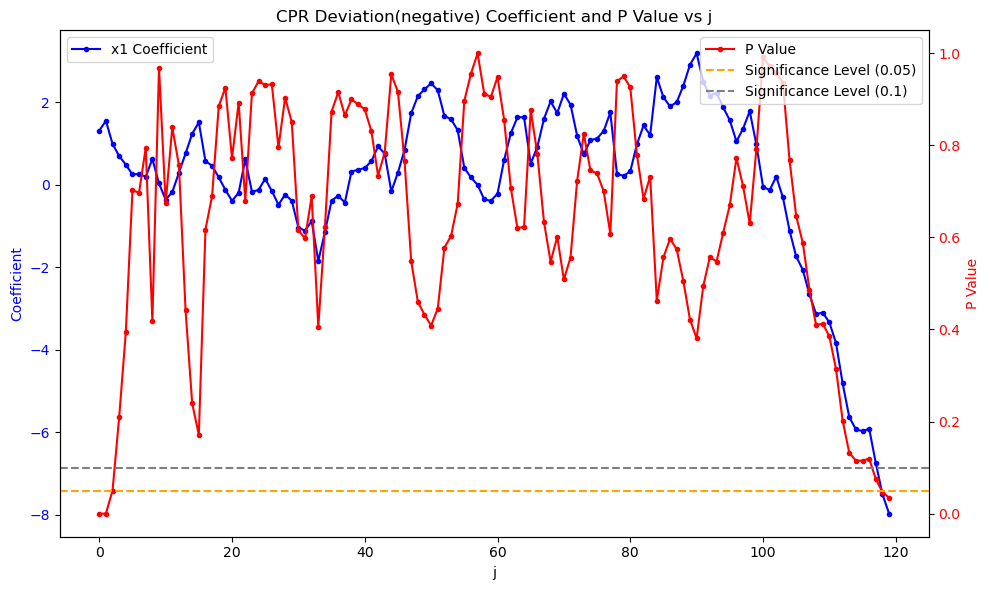

In [8]:
# 创建一个 DataFrame 来存储回归结果
results_df = pd.DataFrame(columns=['j', 'CPR_deviation_coef'])

# 循环 j 从 0 到 119
for j in range(120):
    # 定义因变量 y 和自变量 x1, x2
    y = df[f'j_{j}']
    x1 = df['CPR_deviation']
    x2 = df['CLt-1']
    x3 = df['CLpillar_change']
    x4 = df['NTpillar_change']
    #x5 = df['DTpillar_change']
    
    # 筛选 x1 的数据
    mask = x1 <0
    y_filtered = y[mask]
    X_filtered = pd.DataFrame({'x1': x1[mask], 'x2': x2[mask], 'x3': x3[mask], 'x4': x4[mask]})
    
    # 创建自变量矩阵，并添加常数项
    X = sm.add_constant(X_filtered)
    
    # 进行 OLS 回归
    model = sm.OLS(y_filtered, X, missing='drop').fit()
    
    # 提取 CPR_deviation 的回归系数
    cpr_coef = model.params['x1']
    
    # 提取 p-value
    p_value = model.pvalues['x1']
    
    # 将结果添加到结果 DataFrame
    results_df = results_df.append({'j': j, 'CPR_deviation_coef': cpr_coef, 'p_value': p_value}, ignore_index=True)

# 绘制折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 x1 系数
ax1.plot(results_df['j'], results_df['CPR_deviation_coef'], marker='o', markersize=3, label='x1 Coefficient', color='b')
ax1.set_xlabel('j')
ax1.set_ylabel('Coefficient', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧的 y 轴
ax2 = ax1.twinx()
ax2.plot(results_df['j'], results_df['p_value'], marker='o', markersize=3, label='P Value', color='r')
ax2.set_ylabel('P Value', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 添加 p 值水平线
ax2.axhline(0.05, color='orange', linestyle='--', label='Significance Level (0.05)')
ax2.axhline(0.1, color='grey', linestyle='--', label='Significance Level (0.1)')

# 设置图表标题和图例
plt.title('CPR Deviation(negative) Coefficient and P Value vs j')
fig.tight_layout()  # 适配布局
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 关闭网格
ax1.grid(False)
ax2.grid(False)

plt.savefig('21-24CPR_deviation_negative_regression_results.png')  # 保存图像
plt.show()  # 显示图像

# 将回归结果保存到新的 Excel 文件
results_df.to_excel('21-24CPR_deviation_negative_regression_results.xlsx', index=False)